In [5]:
import sys
import os

# This adds the parent directory (Neural-Network-Scratch) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt
from src.model import forward_propagation, compute_cost, backward_propagation, update_parameters
from src.layers import init_params
from utils.data_loader import load_mnist_data
from utils.preprocessing import prepare_data

# Load and prepare
X_raw, Y_raw = load_mnist_data('../data/mnist_train.csv')
X_train, Y_train = prepare_data(X_raw, Y_raw)

# Define architecture: 784 pixels -> 64 hidden -> 32 hidden -> 10 output
dims = [784, 64, 32, 10]
params = init_params(dims)

Epoch 0, Cost: 2.3739
Epoch 10, Cost: 1.6374
Epoch 20, Cost: 1.1383
Epoch 30, Cost: 0.8526
Epoch 40, Cost: 0.6902
Epoch 50, Cost: 0.5919
Epoch 60, Cost: 0.5282
Epoch 70, Cost: 0.4839
Epoch 80, Cost: 0.4515
Epoch 90, Cost: 0.4268
Epoch 100, Cost: 0.4073
Epoch 110, Cost: 0.3915
Epoch 120, Cost: 0.3783
Epoch 130, Cost: 0.3671
Epoch 140, Cost: 0.3573
Epoch 150, Cost: 0.3488
Epoch 160, Cost: 0.3411
Epoch 170, Cost: 0.3342
Epoch 180, Cost: 0.3279
Epoch 190, Cost: 0.3222
Epoch 199, Cost: 0.3173


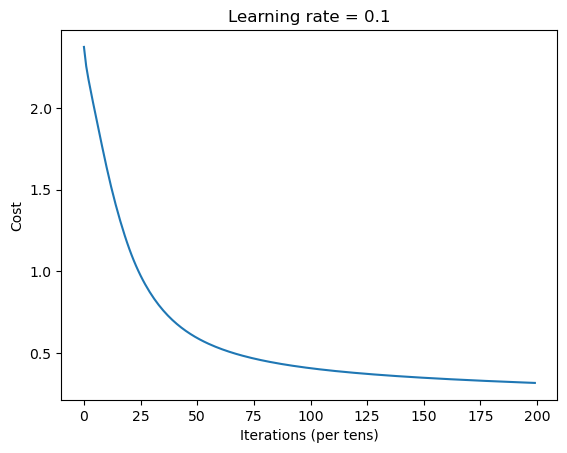

In [6]:
def train_with_visuals(X, Y, params, epochs=100, lr=0.1):
    costs = []
    
    for i in range(epochs):
        # 1. Forward Pass
        AL, caches = forward_propagation(X, params)
        
        # 2. Compute Cost
        cost = compute_cost(AL, Y)
        costs.append(cost)
        
        # 3. Backward Pass (The Math Engine)
        grads = backward_propagation(AL, Y, caches)
        
        # 4. Update Weights
        params = update_parameters(params, grads, lr)
        
        if i % 10 == 0 or i == epochs - 1:
            print(f"Epoch {i}, Cost: {cost:.4f}")
            
    # Plotting the learning curve
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per tens)')
    plt.title(f"Learning rate = {lr}")
    plt.show()
    
    return params

# Start the training
final_params = train_with_visuals(X_train, Y_train, params, epochs=200, lr=0.1)

Epoch 0, Cost: 2.3976
Epoch 10, Cost: 1.7414
Epoch 20, Cost: 1.2342
Epoch 30, Cost: 0.8956
Epoch 40, Cost: 0.7059
Epoch 50, Cost: 0.5981
Epoch 60, Cost: 0.5319
Epoch 70, Cost: 0.4877
Epoch 80, Cost: 0.4563
Epoch 90, Cost: 0.4327
Epoch 100, Cost: 0.4141
Epoch 110, Cost: 0.3989
Epoch 120, Cost: 0.3861
Epoch 130, Cost: 0.3751
Epoch 140, Cost: 0.3654
Epoch 150, Cost: 0.3568
Epoch 160, Cost: 0.3491
Epoch 170, Cost: 0.3420
Epoch 180, Cost: 0.3354
Epoch 190, Cost: 0.3294
Epoch 199, Cost: 0.3243


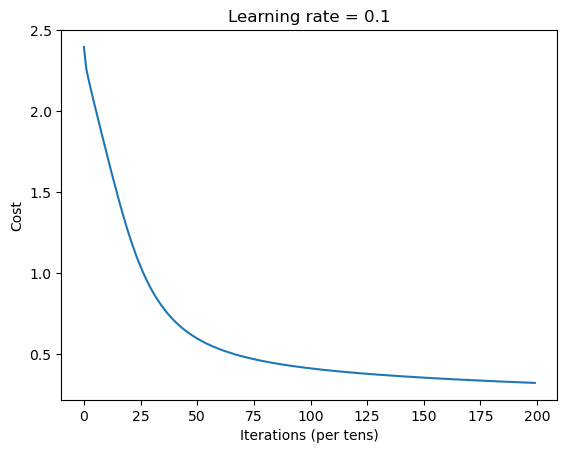

In [7]:
# Use the best LR found in your experiments
dims = [784, 64, 32, 10]
params = init_params(dims)
final_params = train_with_visuals(X_train, Y_train, params, epochs=200, lr=0.1)

In [8]:
def get_predictions(AL):
    """Returns the index of the highest probability."""
    return np.argmax(AL, axis=0)

def get_accuracy(predictions, Y):
    """Calculates the percentage of correct labels."""
    # Y is one-hot, so we need the index of the 1
    labels = np.argmax(Y, axis=0)
    return np.sum(predictions == labels) / labels.size

In [9]:
# 1. Load Test Data
X_test_raw, Y_test_raw = load_mnist_data('../data/mnist_test.csv')
X_test, Y_test = prepare_data(X_test_raw, Y_test_raw)

# 2. Get Test Predictions
AL_test, _ = forward_propagation(X_test, final_params)
test_predictions = get_predictions(AL_test)

# 3. Final Accuracy
test_acc = get_accuracy(test_predictions, Y_test)
print(f"Final Model Test Accuracy: {test_acc * 100:.2f}%")

Final Model Test Accuracy: 91.19%


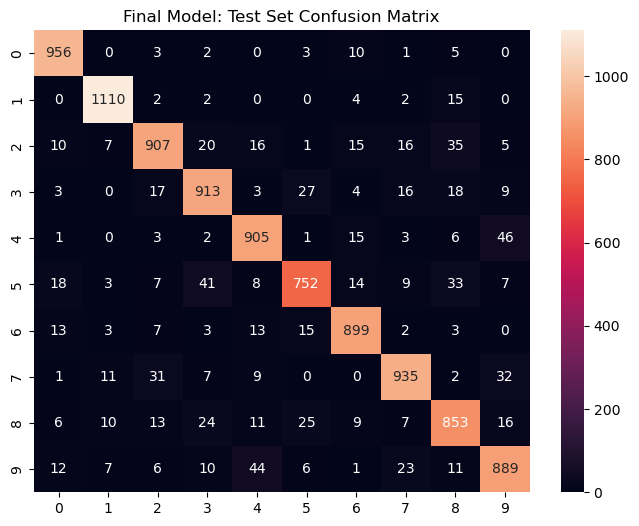

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_true = np.argmax(Y_test, axis=0)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(test_true, test_predictions), annot=True, fmt='d')
plt.title("Final Model: Test Set Confusion Matrix")
plt.show()